# 02 · The model ladder

**Purpose.** Take the data understanding from notebook 01 and turn it into a decision:
which recommendation approach we would build, and on what evidence.

**How to read this.** Every model is fitted through the `recommender` package — nothing
is re-implemented in a cell, so what you see here is exactly what
`scripts/run_model.py` measures and exactly what `docs/RESULTS.md` records. The ladder
is deliberately walked in order, cheapest first, and each rung has to justify itself
against the one below.

**The item is a *work*, not an ISBN.** This is the one structural change since the first
run (milestone M12). Book-Crossing keys everything by ISBN, so *Crime and Punishment*
is 21 different items sharing 141 interactions. Merging editions **before** training —
and before the split — is the basis the primary table below is measured on. The original
ISBN-keyed run is not deleted: it is §5, and the difference between the two tables turned
out to be more interesting than either table alone.

**The honest summary, before any of the numbers.** No single model wins. Accuracy and
catalogue coverage run in almost exactly opposite directions, so the choice is a design
decision about what the product is for — not a leaderboard.

Runtime: about twenty minutes on a laptop — both tables, most of it the two TF-IDF
evaluations.


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from recommender.benchmark import build_bench, ceilings
from recommender.data import load
from recommender.eval import comparison_table, evaluate, hit_rate_at_k_by_group
from recommender.gallery import build_gallery
from recommender.models import ALL_MODELS, build_model, fit_model
from recommender.serving import blank_owned_works, duplicate_slot_rate

pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 46)

started = time.perf_counter()
catalog = load()
works = catalog.works          # the ISBN -> work map, used by both bases below
print(f"loaded {len(catalog.ratings):,} ratings, {len(catalog.books):,} books "
      f"({catalog.n_repaired} malformed rows repaired) in {time.perf_counter() - started:.0f}s")
print(f"{len(catalog.books):,} ISBNs cluster into {works.n_works:,} works")


loaded 1,149,780 ratings, 271,360 books (3 malformed rows repaired) in 3s
271,360 ISBNs cluster into 235,824 works


---
## 1 · The split, and why it is the most important cell in this notebook

Every number below is only as trustworthy as the split it was measured on, so the split
is defined once, in `recommender.split`, and every model cites it.

**Per-user leave-one-out, seed 42.** A user is eligible if they have at least 5 explicit
ratings *and* at least one rating of 8 or more — the first so a profile survives the
holdout, the second so there is something worth predicting. One item is held out per
eligible user, drawn at random from their ratings ≥ 8. Everything else is train,
including all 716,109 implicit interactions and every interaction of non-eligible users.

**Why not a temporal split.** `Ratings.csv` has no time column at all. "Train on the
past, test on the future" is not expressible on this dataset. With client production
logs we would split temporally, and a random split there would leak future behaviour
into training. Saying this plainly is more useful than describing a split the data
cannot support.

**The order matters at work level.** The interactions are re-keyed to works *before* the
split is drawn, so holding out a work removes every edition of it from that user's
profile at once. And the canonical title+author each work carries into the content models
is that of its most-interacted edition, counted **on train only** — otherwise the holdout
would get a vote on which edition's text represents the work. `build_bench` owns that
ordering so no call site can get it wrong.


In [2]:
bench = build_bench(work_level=True, catalog=catalog)
split, train = bench.split, bench.train

print(bench.describe())
print(f"\ntrain matrix: {train.n_users:,} users x {train.n_items:,} items, {train.matrix.nnz:,} interactions")

# Leakage check, run in the notebook rather than asserted in prose.
holdout_in_train = sum(
    1
    for user, item in zip(split.test["User-ID"], split.test["ISBN"], strict=True)
    if (r := train.user_index.get(int(user))) is not None
    and (c := train.item_index.get(item)) is not None
    and train.matrix[r, c] != 0
)
print(f"held-out pairs found in the train matrix: {holdout_in_train}  (must be 0)")

# The second check exists only at work level: at ISBN level a held-out edition could have
# a sibling edition sitting in the same user's train profile — a near-free hit. Here the
# holdout is the whole work, so every edition of it leaves train together. This counts how
# often that actually applied.
held = set(zip(split.test["User-ID"], split.test["ISBN"], strict=True))
pairs = (
    catalog.ratings.assign(work=works.of(catalog.ratings["ISBN"]))
    .groupby(["User-ID", "work"], sort=False)
    .size()
)
multi = sum(1 for key, n in pairs.items() if n > 1 and key in held)
print(f"held-out works the user owned under more than one ISBN: {multi:,} of {len(held):,} "
      f"({multi / len(held):.2%}) — all of their editions left train together")


work level · 235,824 items in the coverage denominator · leave-one-out, seed=42: eligible = users with >=5 explicit ratings and >=1 rating >=8; one held-out item per eligible user drawn from their ratings >=8. 13,580 eligible users, 1,129,755 train interactions.

train matrix: 105,283 users x 303,381 items, 1,129,755 interactions


held-out pairs found in the train matrix: 0  (must be 0)


held-out works the user owned under more than one ISBN: 35 of 13,580 (0.26%) — all of their editions left train together


### The ceiling nobody can beat

Before measuring any model, it is worth knowing what perfect would look like — because
it is not 100%.


In [3]:
bound = ceilings(bench)

print(f"held-out works that appear at all in the train matrix : {bound.collaborative:.2%}"
      "   <- ceiling for ANY collaborative model")
print(f"held-out works that have catalogue metadata           : {bound.content:.2%}   <- ceiling for a content model")
print(f"held-out works reachable by one or the other          : {bound.union:.2%}   <- ceiling for a hybrid")
print(f"\n{1 - bound.collaborative:.1%} of held-out works were that work's ONLY interaction in the dataset.")
print("No co-occurrence model can rank an item it has never seen. Read every HitRate below")
print(f"against {bound.collaborative:.1%}, not against 100%.")


held-out works that appear at all in the train matrix : 86.66%   <- ceiling for ANY collaborative model
held-out works that have catalogue metadata           : 88.98%   <- ceiling for a content model
held-out works reachable by one or the other          : 95.34%   <- ceiling for a hybrid

13.3% of held-out works were that work's ONLY interaction in the dataset.
No co-occurrence model can rank an item it has never seen. Read every HitRate below
against 86.7%, not against 100%.


**Takeaway.** The gap between the collaborative ceiling and the union is the coverage
argument for a hybrid, expressed as a bound on achievable accuracy rather than as a
slogan. It is the single most useful number in this notebook — and note how little
merging editions moved it (ISBN level: 84.81% / 89.31% / 95.37%, ledger L20–L21). The
hybrid argument is invariant to the re-base, which is worth knowing before leaning on it.


---
## 2 · Walking the ladder

Each model is fitted on train only and scored with the same three metrics:

- **HitRate@10** — share of users whose held-out book is in their top-10. Under
  leave-one-out this *equals* Recall@10, and Precision@10 = HitRate@10 / 10. One number,
  three names; reporting all three would be one measurement dressed up as corroboration.
- **Coverage@10** — distinct catalogue items appearing in anyone's top-10, over the whole
  catalogue. At this level that denominator is **235,824 works**, not 271,360 ISBNs, and
  it is the same denominator in every row — mixing the two is the mistake ledger L46
  records.
- **Novelty@10** — mean `-log2` smoothed popularity share. Higher means deeper in the tail.

Accuracy alone cannot be the verdict here: with the top 1% of books holding 25.1% of all
interactions, a model can win HitRate by recommending bestsellers to everybody.

**Hyperparameters were re-validated at this level** (M12.2), on a validation split carved
out of train (seed 43) — never on the evaluation holdout. `build_model(..., work_level=True)`
reads whichever parameter set won that sweep.


In [4]:
results, models, work_result = [], {}, {}


def run(name, label=None):
    """Fit on train, evaluate on the pinned split, keep the model for the gallery.

    Fitting goes through recommender.models.fit_model -- the same dispatch
    scripts/run_model.py uses -- so the notebook and the ledger cannot drift apart
    about which matrix a model was trained on.

    Results are kept twice on purpose: `results` in run order for the table and the
    chart, and `work_result` keyed by registry name, because §5 has to line each row up
    with its ISBN-level counterpart and positional zipping across two different orderings
    is exactly how a comparison table silently swaps two models.
    """
    model = build_model(name, work_level=True)
    t0 = time.perf_counter()
    fit_model(model, train, bench.catalog, split.train)
    fit_seconds = time.perf_counter() - t0
    result = evaluate(
        model, split, train, catalog_isbns=bench.catalog_ids, catalog_size=bench.catalog_size
    )
    results.append(result)
    work_result[name] = result
    models[label or model.name] = model
    print(f"{result}   [fit {fit_seconds:.0f}s]")
    return result


_ = run("popularity")


popularity                   HitRate@10=0.0155  Coverage@10=0.027%  Novelty@10=10.54  (13,580 users, 1s)   [fit 0s]


### 2.1 · Popularity — the reference row

Not a recommender: it hands nearly the same ten books to everyone. It is here because
it calibrates everything else. On a catalogue where the top 1% of books absorb a quarter
of all interactions, "recommend the bestsellers" is a genuinely strong bet.

The interesting half of its row is coverage.


In [5]:
recommended = work_result["popularity"].recommendations
distinct = {item for item in recommended.ravel().tolist() if item is not None}
print(f"distinct works the baseline ever recommends, "
      f"across all {len(split.test):,} users: {len(distinct)}")
print(f"share of the {bench.catalog_size:,}-work catalogue: {len(distinct) / bench.catalog_size:.3%}\n")

# Where does its hit rate actually come from?
support = np.array([
    train.item_popularity[train.item_index[b]] if b in train.item_index else 0
    for b in split.test["ISBN"]
])
hits = (recommended == split.test["ISBN"].to_numpy().reshape(-1, 1)).any(axis=1)
print(f"{'held-out work support':>22} {'users':>7} {'HitRate@10':>11}")
for lo, hi, label in [(0, 0, "0 (unreachable)"), (1, 4, "1-4"), (5, 49, "5-49"), (50, 10**9, "50+")]:
    mask = (support >= lo) & (support <= hi)
    print(f"{label:>22} {mask.sum():>7,} {hits[mask].mean():>11.4f}")


distinct works the baseline ever recommends, across all 13,580 users: 64
share of the 235,824-work catalogue: 0.027%

 held-out work support   users  HitRate@10
       0 (unreachable)   1,812      0.0000
                   1-4   2,410      0.0000
                  5-49   4,591      0.0000
                   50+   4,767      0.0443


**Takeaway.** The baseline is not a *weak* benchmark, it is a **narrow** one. It scores
essentially zero for every user whose held-out book has few interactions, and its entire
hit rate comes from users who were going to be given a bestseller anyway. The aggregate
number hides this completely, which is a good argument for never reporting a single
aggregate.


### 2.2 · Item-item CF — the core hypothesis

The product takes a book and returns similar books, with no user identity at query time.
Item-item answers exactly that question natively: the model *is* a table of book
neighbourhoods.

Similarity is **shrunk cosine** over the binarized interaction matrix:
`co_occurrence(i,j) / (sqrt(support_i · support_j) + λ)`. Plain cosine is hostile here —
58% of books have exactly one rating, so two books sharing their single reader score a
perfect 1.0, and a similarity built from one coincidence outranks one built from four
hundred readers. The shrinkage term costs popular pairs almost nothing and divides
one-off pairs by a constant they cannot compete with.

λ and the neighbourhood size were re-swept on the **work-level** validation split
(seed 43) in M12.2, never on the evaluation holdout — see ledger L51.


In [6]:
_ = run("item-item")
_ = run("item-item-explicit", label="item-item (explicit-only)")


item-item                    HitRate@10=0.0644  Coverage@10=8.190%  Novelty@10=14.17  (13,580 users, 2s)   [fit 22s]


item-item (explicit-only)    HitRate@10=0.0486  Coverage@10=10.036%  Novelty@10=15.97  (13,580 users, 1s)   [fit 5s]


Note what the second row is. It is the *same model* on a matrix built from graded
ratings alone — the ablation that turns the signal decision into a measurement instead
of an assumption.


In [7]:
binary = work_result["item-item"]
explicit = work_result["item-item-explicit"]
print(f"all interactions (binarized): HitRate@10 = {binary.hit_rate_at_10:.4f}")
print(f"explicit ratings only       : HitRate@10 = {explicit.hit_rate_at_10:.4f}")
print(f"\ncost of discarding the 62.3% of rows that carry no grade: "
      f"{1 - explicit.hit_rate_at_10 / binary.hit_rate_at_10:.0%} of the hit rate")
print(f"but explicit-only wins on coverage: {explicit.coverage_at_10:.3%} vs {binary.coverage_at_10:.3%}")


all interactions (binarized): HitRate@10 = 0.0644
explicit ratings only       : HitRate@10 = 0.0486

cost of discarding the 62.3% of rows that carry no grade: 24% of the hit rate
but explicit-only wins on coverage: 10.036% vs 8.190%


**Takeaway.** An ungraded interaction is weaker evidence than a 10, but it is not noise —
discarding it costs a quarter to a third of the hit rate. The counter-current is real and
belongs in the same sentence: the sparser explicit-only matrix spreads its recommendations
more thinly, so it *wins* on coverage and novelty. Binarized-everything wins where it
counts and loses where it does not.


### 2.3 · ALS — the same story one rung up

ALS is not an alternative to item-item, it is a continuation of it: the item factors
*are* item embeddings, and similarity is a dot product between them. It also produces
user factors from the same fit, so personalization comes free the day the product knows
who is asking — and it is the one model here with a first-class Spark implementation,
which makes the Part 3 Databricks story a port rather than a rewrite.

The explicit ratings earn their keep here as **confidence weights**: the matrix carries
`1 + α·rating`, so an ungraded interaction still counts (confidence 1) while a book
graded 10 counts eleven times as much. Note what this does *not* claim — a low rating is
not a negative signal. ALS can express strength of positive evidence and nothing else.


In [8]:
_ = run("als")


als                          HitRate@10=0.0545  Coverage@10=0.897%  Novelty@10=12.29  (13,580 users, 36s)   [fit 91s]


**Takeaway.** ALS loses to item-item on all three metrics at once, which is what the
literature predicts for data this sparse — and the popularity-bias study run *on
Book-Crossing specifically* (Naghiaei et al. 2022) flags matrix-factorization models as
bias amplifiers. Measuring it beats citing it. ALS stays in the ladder for the free
personalization and the Spark bridge, not for its score. §4 shows the one thing it is
clearly best at.


### 2.4 · The content layers — reaching the catalogue CF cannot see

Both content models score a book from its title and author, so both can rank a book
nobody has ever touched. That is the entire point: collaborative filtering is
structurally blind to the works that appear nowhere in train and, after standard
filtering, to almost the whole catalogue.

**TF-IDF** uses character n-grams rather than words, deliberately — the catalogue is
multilingual and riddled with edition variants, and character n-grams degrade gracefully
across both where a word vocabulary would treat *Ringe* and *Rings* as unrelated.

**Embeddings** use a multilingual sentence transformer, which places *Der Herr der Ringe*
near *The Lord of the Rings* because it was trained to rather than because they share
characters.

Both now read **one row per work**, carrying the title and author of that work's
most-interacted edition. Their vectors are therefore a different set from the ISBN-level
run's; the embedding cache is keyed by a fingerprint of the text it encoded, so the two
sets live side by side under `artifacts/` instead of overwriting each other.


In [9]:
_ = run("tfidf")        # the slow one
_ = run("embeddings")   # fast, vectors come from the cache


content-tfidf                HitRate@10=0.0405  Coverage@10=16.806%  Novelty@10=17.07  (13,580 users, 262s)   [fit 10s]


content-embeddings           HitRate@10=0.0141  Coverage@10=26.143%  Novelty@10=18.34  (13,580 users, 29s)   [fit 1s]


**Takeaway.** Both reach far more of the catalogue than any collaborative model and both
score worse — the embedding layer lands *below the popularity baseline* on accuracy. That
is the honest shape of a content layer: it is a coverage and cold-start mechanism, not a
scoring core, and it would be dishonest to promote the embedding model simply because it
is the deep-learning component.


---
## 3 · The primary comparison table

Same split, same metrics, same run, one item universe: **works**.


In [10]:
table = comparison_table(results).drop(columns=["params"]).sort_values("HitRate@10", ascending=False)
display(table.reset_index(drop=True))


,model,HitRate@10,Coverage@10,Novelty@10,users,seconds
0,item-item,0.0644,0.08190,14.17,13580,2.0
1,als,0.0545,0.00897,12.29,13580,35.8
2,item-item (explicit-only),0.0486,0.10036,15.97,13580,0.8
3,content-tfidf,0.0405,0.16806,17.07,13580,261.6
4,popularity,0.0155,0.00027,10.54,13580,0.7
5,content-embeddings,0.0141,0.26143,18.34,13580,29.1


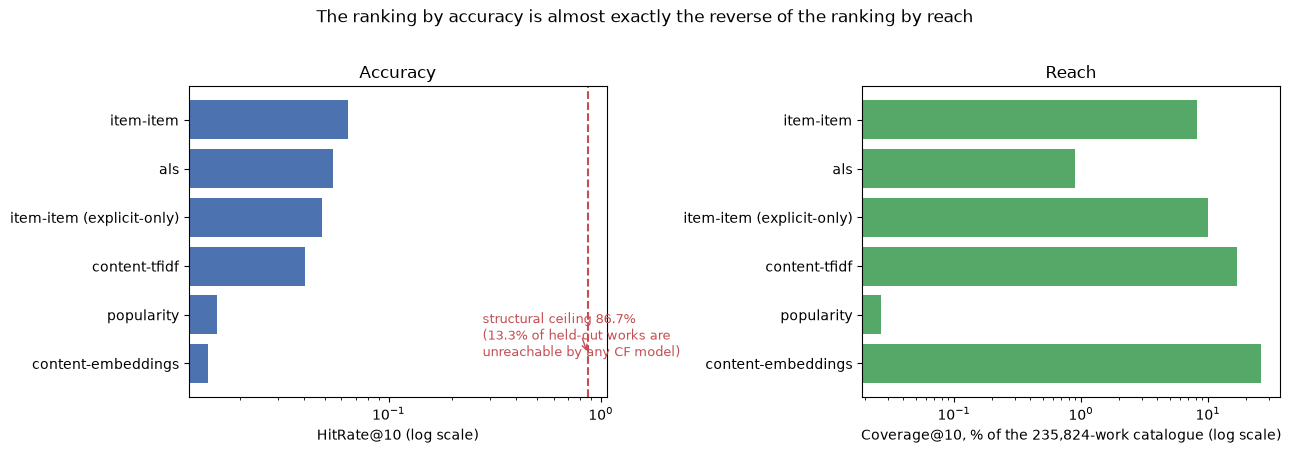

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ordered = sorted(results, key=lambda r: r.hit_rate_at_10)
labels = [r.model for r in ordered]

axes[0].barh(labels, [r.hit_rate_at_10 for r in ordered], color="#4c72b0")
axes[0].axvline(bound.collaborative, color="#c44e52", linestyle="--")
note = (f"structural ceiling {bound.collaborative:.1%}\n"
        f"({1 - bound.collaborative:.1%} of held-out works are\nunreachable by any CF model)")
axes[0].annotate(note, xy=(bound.collaborative, 0.2), xytext=(bound.collaborative * 0.32, 0.15),
                 color="#c44e52", fontsize=9, arrowprops={"arrowstyle": "->", "color": "#c44e52"})
axes[0].set_xscale("log")
axes[0].set_xlabel("HitRate@10 (log scale)")
axes[0].set_title("Accuracy")

axes[1].barh(labels, [r.coverage_at_10 * 100 for r in ordered], color="#55a868")
axes[1].set_xscale("log")
axes[1].set_xlabel(f"Coverage@10, % of the {bench.catalog_size:,}-work catalogue (log scale)")
axes[1].set_title("Reach")

fig.suptitle("The ranking by accuracy is almost exactly the reverse of the ranking by reach", y=1.02)
fig.tight_layout()
plt.show()


In [12]:
# The hybrid argument is a claim about *complementarity*, so measure the overlap rather
# than inferring it from two coverage percentages.
reach = {
    name: {i for i in work_result[name].recommendations.ravel().tolist() if i in bench.catalog_ids}
    for name in ("item-item", "tfidf", "embeddings")
}
cf, text = reach["item-item"], reach["tfidf"]
print(f"item-item reaches      {len(cf):>7,} works ({len(cf) / bench.catalog_size:.2%})")
print(f"TF-IDF reaches         {len(text):>7,} works ({len(text) / bench.catalog_size:.2%})")
print(f"they overlap on        {len(cf & text):>7,} works")
print(f"together they reach    {len(cf | text):>7,} works ({len(cf | text) / bench.catalog_size:.2%})")
print(f"...plus embeddings     {len(cf | text | reach['embeddings']):>7,} works "
      f"({len(cf | text | reach['embeddings']) / bench.catalog_size:.2%})")


item-item reaches       19,313 works (8.19%)
TF-IDF reaches          39,632 works (16.81%)
they overlap on          6,794 works
together they reach     52,151 works (22.11%)
...plus embeddings      93,992 works (39.86%)


**Takeaway.** The table has a shape, and the shape *is* the finding: the accuracy ranking
is almost exactly the reverse of the coverage ranking, with ALS the only exception. There
is no single best model here, so "which model" is the wrong question — the right one is
"which model for which job". The overlap above is the hybrid argument as a measurement:
the two model classes are reaching largely *different* parts of the catalogue, which is
what makes combining them worth more than picking the better one.

The shape survived the re-base unchanged, which is the reassuring part of §5: the same
ordering, the same tension, on a different item universe.


---
## 4 · Face validity: what each model thinks a book is like

The offline harness scores **user histories**. The product is **item-to-item**: paste a
book, get similar books. Those are different questions, and a HitRate cannot see whether
the neighbourhoods a model builds are sensible.

So every model answers the same three books. *The Da Vinci Code* is the easy case.
*The Lovely Bones* checks we are not just reproducing one genre cluster. **Harry Potter
and the Sorcerer's Stone** is the diagnostic — medium support, an obvious right answer
(the other volumes), and the catalogue holds 120 Harry Potter rows across editions and
languages, which at this level are one item.


In [13]:
gallery = build_gallery(list(models.values()), bench.catalog, anchors=bench.anchors, k=5)
for label, table in gallery.items():
    print(f"\n=== similar to: {label} ===")
    display(table)



=== similar to: The Da Vinci Code ===


,popularity,item-item,item-item (explicit-only),als,content-tfidf,content-embeddings
rank,,,,,,
1,Wild Animus — Rich Shapero (2500.000),Angels &amp; Demons — Dan Brown (0.269),Angels &amp; Demons — Dan Brown (0.148),Angels &amp; Demons — Dan Brown (0.568),El Codigo Da Vinci / The Da Vinci Code — D...,El Codigo Da Vinci / The Da Vinci Code — D...
2,The Lovely Bones: A Novel — Alice Sebold ...,The Lovely Bones: A Novel — Alice Sebold ...,Middlesex: A Novel — Jeffrey Eugenides (0...,Stupid White Men : ...And Other Sorry Excu...,The Da Vinci Hoax: Exposing the Errors in ...,Secrets of the Code: The Unauthorized Guid...
3,She's Come Undone (Oprah's Book Club) — Wa...,Life of Pi — Yann Martel (0.172),Digital Fortress : A Thriller — Dan Brown ...,Digital Fortress : A Thriller — Dan Brown ...,Secrets of the Code: The Unauthorized Guid...,Bengal Station — Eric Brown (0.573)
4,Harry Potter and the Sorcerer's Stone (Har...,The Secret Life of Bees — Sue Monk Kidd (...,The Secret Life of Bees — Sue Monk Kidd (...,Trojan Odyssey — Clive Cussler (0.412),Cracking the Da Vinci Code : The Unauthori...,The Da Vinci Hoax: Exposing the Errors in ...
5,The Nanny Diaries: A Novel — Emma McLaughl...,Harry Potter and the Order of the Phoenix ...,The Lovely Bones: A Novel — Alice Sebold ...,The Eight — Katherine Neville (0.405),Matter — Dan Brown (0.415),Bushido Code — Robert St Louis (0.528)



=== similar to: Harry Potter and the Sorcerer's Stone ===


,popularity,item-item,item-item (explicit-only),als,content-tfidf,content-embeddings
rank,,,,,,
1,Wild Animus — Rich Shapero (2500.000),Harry Potter and the Chamber of Secrets (B...,Harry Potter and the Chamber of Secrets (B...,Harry Potter and the Chamber of Secrets (B...,Harry Potter and the Sorcerer's Stone: A D...,Harry Potter and the Sorcerer's Stone: A D...
2,The Lovely Bones: A Novel — Alice Sebold ...,Harry Potter and the Prisoner of Azkaban (...,Harry Potter and the Prisoner of Azkaban (...,Harry Potter and the Prisoner of Azkaban (...,Harry Potter and the Sorcerer's Stone — M...,Harry Potter E la Pietra Filosfale — J. K....
3,She's Come Undone (Oprah's Book Club) — Wa...,Harry Potter and the Goblet of Fire (Book ...,Harry Potter and the Goblet of Fire (Book ...,Harry Potter and the Goblet of Fire (Book ...,Harry Potter and the Sorcerer's Stone Movi...,Harry Potter a l'ecole des sorciers — J. K...
4,The Da Vinci Code — Dan Brown (873.000),Harry Potter and the Order of the Phoenix ...,Harry Potter and the Order of the Phoenix ...,Harry Potter and the Order of the Phoenix ...,Harry Potter and the Philosopher's Stone —...,Harry Potter y la cÃ¡mara secreta — J. K. ...
5,The Nanny Diaries: A Novel — Emma McLaughl...,The Fellowship of the Ring (The Lord of th...,The Fellowship of the Ring (The Lord of th...,Fever 1793 — Laurie Halse Anderson (0.352),"Harry Potter, tome 4 : Harry Potter et la ...",Harry Potter and the Philosopher's Stone —...



=== similar to: The Lovely Bones ===


,popularity,item-item,item-item (explicit-only),als,content-tfidf,content-embeddings
rank,,,,,,
1,Wild Animus — Rich Shapero (2500.000),Lucky : A Memoir — Alice Sebold (0.207),Lucky : A Memoir — Alice Sebold (0.100),Lucky : A Memoir — Alice Sebold (0.478),The Lovely Bones — Alice Sebold (0.898),The Lovely Bones — Alice Sebold (0.916)
2,She's Come Undone (Oprah's Book Club) — Wa...,The Nanny Diaries: A Novel — Emma McLaughl...,She's Come Undone (Oprah's Book Club) — Wa...,Lucky — Alice Sebold (0.355),Lucky — Alice Sebold (0.583),The Bone Vault: A Novel — Linda Fairstein ...
3,The Da Vinci Code — Dan Brown (873.000),The Secret Life of Bees — Sue Monk Kidd (...,Lucky — Alice Sebold (0.086),Blessings — ANNA QUINDLEN (0.345),Lucky : A Memoir — Alice Sebold (0.515),The Bone Vault : A Novel — Linda Fairstein...
4,Harry Potter and the Sorcerer's Stone (Har...,She's Come Undone (Oprah's Book Club) — Wa...,The Da Vinci Code — Dan Brown (0.084),Being Digital — Nicholas Negroponte (0.319),Desde Mi Cielo — Alice Sebold (0.457),My Sister's Bones: A Novel — Cathi Hanauer...
5,The Nanny Diaries: A Novel — Emma McLaughl...,The Da Vinci Code — Dan Brown (0.178),Where the Heart Is (Oprah's Book Club (Pap...,The Nanny Diaries: A Novel — Emma McLaughl...,In meinem Himmel. — Alice Sebold (0.450),The Bone Garden: A Wesley Peterson Crime N...


**Takeaway — the Harry Potter column is still the whole story, and it changed.**

- **popularity** returns bestsellers. It has no notion of similarity at all; the column is
  a control.
- **item-item now answers correctly**: *Chamber of Secrets*, *Prisoner of Azkaban*, *Goblet
  of Fire*, *Order of the Phoenix* — the four sequels, in order. On the ISBN basis the same
  model with the same λ returned two unrelated obscure books first, which shared four
  readers out of six with the anchor (ledger L29). Nothing about the model changed. Its
  evidence had been split across 120 Harry Potter rows, and shrinkage was correctly
  refusing to trust any single fragment of it. **This is the clearest product-surface
  consequence of the re-base, and no metric in §3 can see it.**
- **the content models** no longer return ten ISBNs of the anchor — that failure is gone by
  construction, because those ISBNs are now one item. What they still return is the anchor
  under a *different title*: *Philosopher's Stone*, the Italian *Pietra Filosfale*, the
  French *à l'école des sorciers*, the Welsh edition, *Desde Mi Cielo* for *The Lovely
  Bones*. A key built on title equality cannot reach those (L47, L59), and that is the
  measured argument for the enrichment layer rather than an opinion about LLMs.
- **ALS still answers the question a reader would ask**, and it is still beaten on every
  metric in §3. The metrics and the product surface measure different things.

That divergence is not a caveat to mention in passing. It is the reason both numbers and
galleries are in this notebook.


---
## 5 · The ISBN-level journey, and what the re-base actually bought

Everything above is measured on works. The project did not start there: the first full run
(M4–M10) keyed items by ISBN, because that is how Book-Crossing ships. That table is kept —
it is the record of how the decision was reached, and it is re-run here rather than quoted,
so the comparison is between two live measurements and not between a measurement and a
memory.

Then the interesting part. Re-basing lifted every model, but it lifted them by wildly
different amounts — TF-IDF by **+78%**, the popularity baseline by **+7%**. A single number
that large is a bug until proven otherwise, so it gets taken apart into the two things the
re-base actually does.


In [14]:
isbn_bench = build_bench(work_level=False, catalog=catalog)
print(isbn_bench.describe())
print(ceilings(isbn_bench).describe(), "\n")

isbn_results = {}
for name in ALL_MODELS:
    model = fit_model(build_model(name), isbn_bench.train, isbn_bench.catalog, isbn_bench.split.train)
    isbn_results[name] = evaluate(
        model, isbn_bench.split, isbn_bench.train,
        catalog_isbns=isbn_bench.catalog_ids, catalog_size=isbn_bench.catalog_size,
    )
    print(isbn_results[name], flush=True)
    del model  # the similarity matrices are large; nothing below needs the fitted model


ISBN level · 271,360 items in the coverage denominator · leave-one-out, seed=42: eligible = users with >=5 explicit ratings and >=1 rating >=8; one held-out item per eligible user drawn from their ratings >=8. 13,581 eligible users, 1,136,199 train interactions.
ceilings at ISBN level over 13,581 holdouts: collaborative 84.81%, content 89.31%, union 95.37% 



popularity                   HitRate@10=0.0145  Coverage@10=0.019%  Novelty@10=10.81  (13,581 users, 1s)


item-item                    HitRate@10=0.0546  Coverage@10=9.064%  Novelty@10=14.91  (13,581 users, 2s)


item-item (explicit-only)    HitRate@10=0.0379  Coverage@10=10.739%  Novelty@10=16.59  (13,581 users, 1s)


content-tfidf                HitRate@10=0.0228  Coverage@10=16.616%  Novelty@10=17.63  (13,581 users, 321s)


als                          HitRate@10=0.0451  Coverage@10=0.835%  Novelty@10=12.63  (13,581 users, 35s)


content-embeddings           HitRate@10=0.0109  Coverage@10=23.911%  Novelty@10=18.42  (13,581 users, 35s)


### 5.1 · What the ISBN basis was doing to the text models

The defect first (ledger L31, L45): how much of each model's top-10 was another *edition*
of a book the reader already had. This is measured with the same work key used everywhere
else, and it is the column that predicts everything in §5.2.


In [15]:
dup = {
    name: duplicate_slot_rate(
        result.recommendations, isbn_bench.split.test["User-ID"].to_numpy(), isbn_bench.train, works
    )
    for name, result in isbn_results.items()
}
print(f"{'model':>22} {'duplicate slots':>16} {'users affected':>16}")
for name, stats in sorted(dup.items(), key=lambda kv: kv[1]["duplicate_slot_share"]):
    print(f"{name:>22} {stats['duplicate_slot_share']:>16.1%} {stats['affected_user_share']:>16.1%}")


                 model  duplicate slots   users affected
            popularity             0.3%             2.7%
             item-item             1.2%             7.9%
                   als             1.9%            11.8%
    item-item-explicit             3.9%            18.4%
            embeddings            11.3%            38.5%
                 tfidf            39.1%            81.5%


### 5.2 · Splitting the lift: evaluation fairness vs merged signal

Re-basing does two separable things, and only one of them is the model getting better.

1. **Evaluation fairness.** At ISBN level, recommending the Penguin edition when the
   reader's held-out book was the Vintage edition scores **zero**. The model named the
   right book and the metric called it wrong. Isolating this needs no re-fit at all: take
   the *same* ISBN-level model, the *same* top-10 lists, and change only the definition of
   a hit, so that any edition of the held-out work counts.
2. **Merged signal.** Everything else — co-occurrence counts that were split across
   editions become one count, the canonical per-work text replaces a pile of near-duplicate
   strings, and a slot wasted on a second edition of the anchor goes to a real candidate.

The middle columns below are the first component. The residual up to the work-level row is
the second.

**And the hole in component 1, closed by measuring it.** Work credit can award a hit the
work-level table never could: if the reader held out one edition of a work and still owns
*another* edition of it in train, then recommending a third edition scores — for a book
they demonstrably already have. At work level that is impossible, because an owned work is
blocked from the candidate list. So the table carries a fourth column that refuses credit
for any slot whose work the reader already owns. It forfeits the slot rather than refilling
it, which makes it a lower bound rather than a second opinion.


In [16]:
holdout = isbn_bench.split.test["ISBN"].to_numpy()
users = isbn_bench.split.test["User-ID"].to_numpy()

rows = []
for name, isbn_result in isbn_results.items():
    base = isbn_result.hit_rate_at_10
    fair = hit_rate_at_k_by_group(isbn_result.recommendations, holdout, works.of)
    owned_blocked = hit_rate_at_k_by_group(
        blank_owned_works(isbn_result.recommendations, users, isbn_bench.train, works), holdout, works.of
    )
    full = work_result[name].hit_rate_at_10
    rows.append({
        "model": name,
        "ISBN basis": base,
        "+ work credit": fair,
        "...owned blocked": owned_blocked,
        "work basis": full,
        "evaluation fairness": fair / base - 1,
        "merged signal": full / fair - 1,
        "total": full / base - 1,
        "ISBN dup slots": dup[name]["duplicate_slot_share"],
    })

decomposition = pd.DataFrame(rows).sort_values("total").reset_index(drop=True)
display(decomposition.assign(**{
    "ISBN basis": decomposition["ISBN basis"].map("{:.4f}".format),
    "+ work credit": decomposition["+ work credit"].map("{:.4f}".format),
    "...owned blocked": decomposition["...owned blocked"].map("{:.4f}".format),
    "work basis": decomposition["work basis"].map("{:.4f}".format),
    "evaluation fairness": decomposition["evaluation fairness"].map("{:+.1%}".format),
    "merged signal": decomposition["merged signal"].map("{:+.1%}".format),
    "total": decomposition["total"].map("{:+.1%}".format),
    "ISBN dup slots": decomposition["ISBN dup slots"].map("{:.1%}".format),
}))


,model,ISBN basis,+ work credit,...owned blocked,work basis,evaluation fairness,merged signal,total,ISBN dup slots
0,popularity,0.0145,0.0155,0.0155,0.0155,+6.6%,+0.5%,+7.1%,0.3%
1,item-item,0.0546,0.0588,0.0586,0.0644,+7.5%,+9.5%,+17.8%,1.2%
2,als,0.0451,0.0503,0.0501,0.0545,+11.4%,+8.4%,+20.7%,1.9%
3,item-item-explicit,0.0379,0.0408,0.0406,0.0486,+7.6%,+19.1%,+28.2%,3.9%
4,embeddings,0.0109,0.0115,0.0112,0.0141,+5.4%,+22.4%,+29.1%,11.3%
5,tfidf,0.0228,0.0250,0.0245,0.0405,+9.4%,+62.3%,+77.4%,39.1%


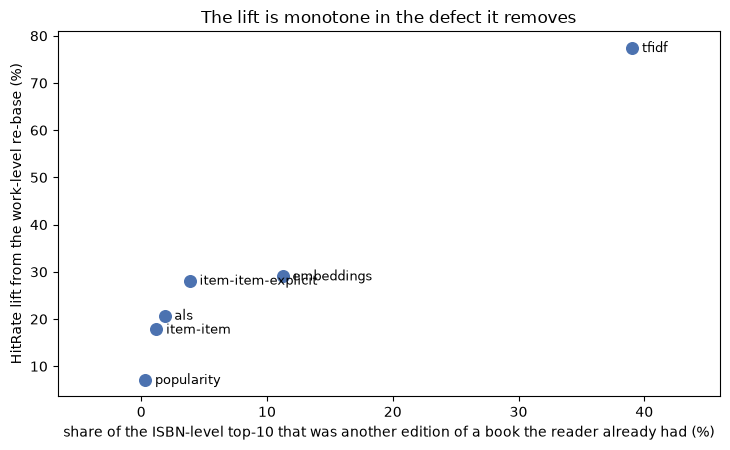

In [17]:
fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.scatter(decomposition["ISBN dup slots"] * 100, decomposition["total"] * 100, s=70, color="#4c72b0")
for _, row in decomposition.iterrows():
    ax.annotate(row["model"], (row["ISBN dup slots"] * 100, row["total"] * 100),
                textcoords="offset points", xytext=(7, -3), fontsize=9)
ax.set_xlabel("share of the ISBN-level top-10 that was another edition of a book the reader already had (%)")
ax.set_ylabel("HitRate lift from the work-level re-base (%)")
ax.set_title("The lift is monotone in the defect it removes")
ax.margins(x=0.18)
fig.tight_layout()
plt.show()


**Takeaway — the mechanism, named.** *ISBN-level evaluation double-penalized the text
models.* They were charged twice for the same property of the data: once on the **output**
side, when a slot went to an edition of a book the reader already had, and again on the
**scoring** side, when the edition they did recommend was the right book under the wrong
ISBN and scored zero. Collaborative models were barely charged the first way at all,
because two ISBNs of one book are read by *different* people and therefore never co-occur —
their similarity separates editions for free. It is exactly the models whose similarity is
textual that suffer, because textually a reprint and its original are the same document.

**And the decomposition says which charge carries the number, which is not the obvious
one.** The scoring-side penalty — the middle column — is small and *roughly uniform across
the whole table*, +5% to +11%, ordered by nothing in particular: ALS has the largest, the
embedding model the smallest. The ISBN key was mildly unfair to everybody. What varies by
two orders of magnitude is the output-side effect, and that is what tracks the
duplicate-slot rate in the scatter above.

So the plausibility gate fired for a good reason and the band was still wrong: the band
assumed the re-base was a re-parameterisation, and for a text model it is also a defect fix.
The gate was right to stop; the first explanation offered on the branch was half right; and
the way to tell was to change one thing at a time.

The practical consequence is a ranking statement, not a scoreboard one: **TF-IDF was
under-rated by the ISBN-keyed table** — by a factor, not a rounding error — so the gap
between the collaborative and content layers is smaller than the first run suggested. It
does not change which model wins.


---
## 6 · What these numbers are not

**They are one split.** Seeded and reproducible, but one draw. No confidence intervals
are reported here, and differences of a few tenths of a percent should not be read as
real.

**They are offline.** Every metric asks "was the held-out book in the top ten", which is a
proxy for "would a reader click, buy, or enjoy this". A recommendation the user has never
heard of scores zero whether it was a brilliant discovery or a mistake. A live A/B test
is the only thing that settles the real question, and that stays true however favourable
this table looks.

**They inherit the dataset's quirks.** A 2004 web crawl with no timestamps, 10.3% of
interactions unjoinable to a book we could display, and — the one §5 is about — an item
key that is an edition rather than a book.

**The clustering itself is measured-imperfect.** 0 wrong merges in a random sample of 30,
1 in 20 of the clusters that the transliteration extension touches (L42), and it cannot
see that *Philosopher's Stone* and *Sorcerer's Stone* are one book (L47).

**What we protected against, and how.** Fitting only ever touched train — the leakage
check at the top of this notebook is run, not asserted. Hyperparameters were chosen on a
validation split carved out of train, at each item level separately, never on the
evaluation holdout. The metrics are the same three for every model, computed by one
function, against one denominator. And the negative results are in `docs/RESULTS.md` next
to the positive ones, because a ledger you can only read one way is a brochure.


---
## 7 · What we would build

**Item-item CF as the scoring core.** It wins accuracy by a clear margin, it answers the
product's actual question natively, it trains in well under a minute, and it is
explainable — "readers of this book also read that one" is a sentence a customer
understands and a shop can defend.

**A content layer beside it, not behind it.** Not as a cold-start footnote: collaborative
filtering is structurally incapable of reaching the works that appear nowhere in train,
and most of the catalogue after standard filtering. The union of both raises the
achievable ceiling by roughly ten points, at either item level.

**ALS kept in the plan, for what the metrics do not show.** Free personalization from the
same fit, the best item-to-item neighbourhoods of any model here, and the only model that
ports to Spark without a rewrite.

**Edition clustering in data prep, not only at serving.** §5 is the argument: it is worth
more than any model choice in this table, and it is the difference between a demo that
works and one that recommends the book the reader is holding. What it does *not* fix is
the same book under a different title — which is the measured case for the metadata
enrichment layer, made twice over (L38, L47).

Every number above traces to a line in [`docs/RESULTS.md`](../docs/RESULTS.md).
